Step 1: import libraries


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Step 2 :Load Dataset


In [ ]:
df = pd.read_csv("/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

Step 3 :Understanding Data

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Step 4 :Data Cleaning

In [ ]:
print("missing values per column:",df.isna().sum().sum())
print("duplicate rows:",df.duplicated().sum())

missing values per column: 0
duplicate rows: 0


In [ ]:
for col in ['gender', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod', 'Churn']:
    print(f"{col}:{df[col].unique()}")

gender:['Female' 'Male']
Partner:['Yes' 'No']
Dependents:['No' 'Yes']
PhoneService:['No' 'Yes']
MultipleLines:['No phone service' 'No' 'Yes']
InternetService:['DSL' 'Fiber optic' 'No']
OnlineSecurity:['No' 'Yes' 'No internet service']
OnlineBackup:['Yes' 'No' 'No internet service']
DeviceProtection:['No' 'Yes' 'No internet service']
TechSupport:['No' 'Yes' 'No internet service']
StreamingTV:['No' 'Yes' 'No internet service']
StreamingMovies:['No' 'Yes' 'No internet service']
Contract:['Month-to-month' 'One year' 'Two year']
PaperlessBilling:['Yes' 'No']
PaymentMethod:['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn:['No' 'Yes']


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)

In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Step 5 :Outlier Detection

In [ ]:
numeric_cols_to_check = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
outlier_bounds = {}

for col in numeric_cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: bounds=({lower:.2f}, {upper:.2f}) -> {outliers} outlier(s)")

SeniorCitizen: bounds=(0.00, 0.00) -> 1142 outlier(s)
tenure: bounds=(-60.00, 124.00) -> 0 outlier(s)
MonthlyCharges: bounds=(-45.82, 171.27) -> 0 outlier(s)
TotalCharges: bounds=(-4688.48, 8884.67) -> 0 outlier(s)


In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


In [ ]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


Step 6 :Exploratory Data Analysis (EDA)

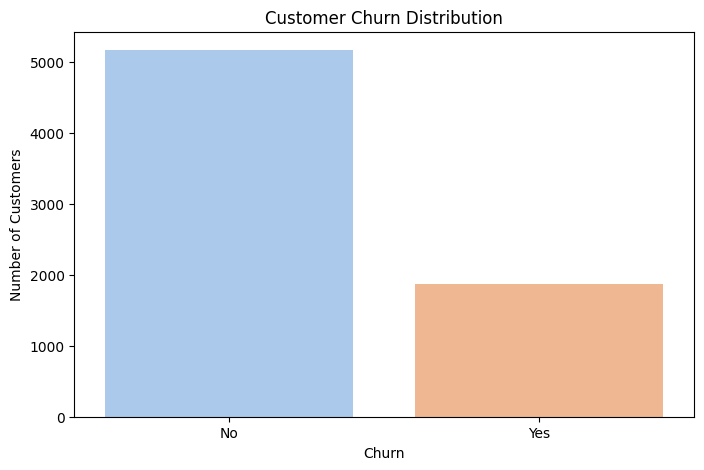

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Churn', hue='Churn', palette='pastel', legend=False)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

Most customers stayed with the company, while a smaller percentage of customers churned.

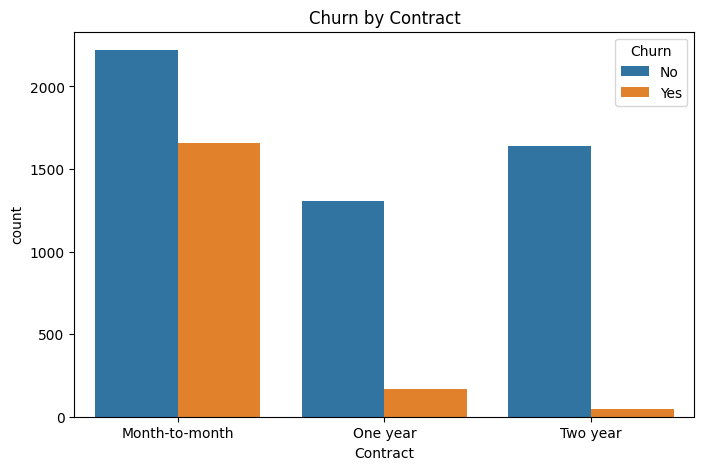

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract")
plt.show()

Customers with month-to-month contracts have the highest churn rate

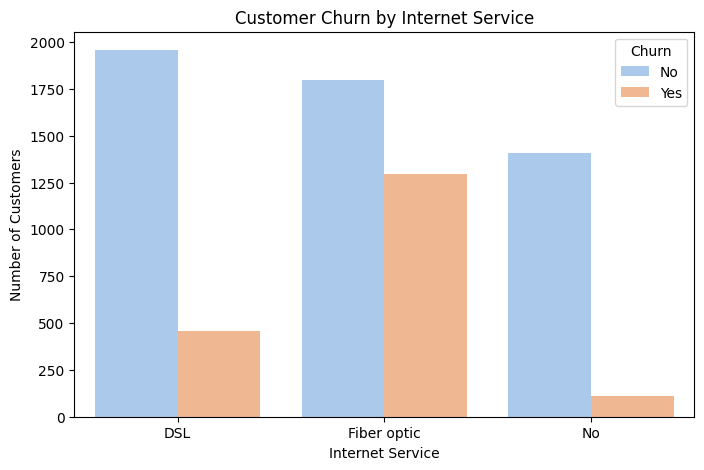

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot( data=df,x='InternetService', hue='Churn',palette='pastel')

plt.title('Customer Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

Customers using Fiber Optic internet show a higher churn rate than customers using other internet service types.

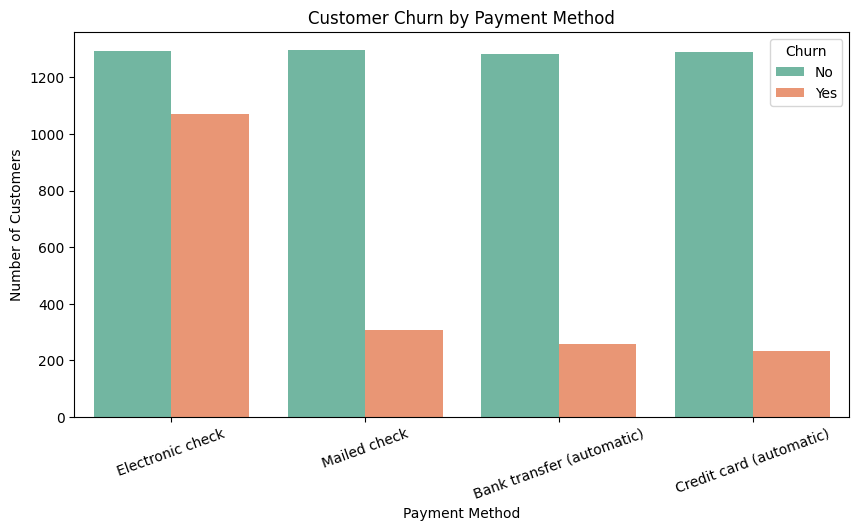

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='PaymentMethod',hue='Churn',palette='Set2')
plt.title('Customer Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.show()

Customers who pay using Electronic Check have the highest churn rate.

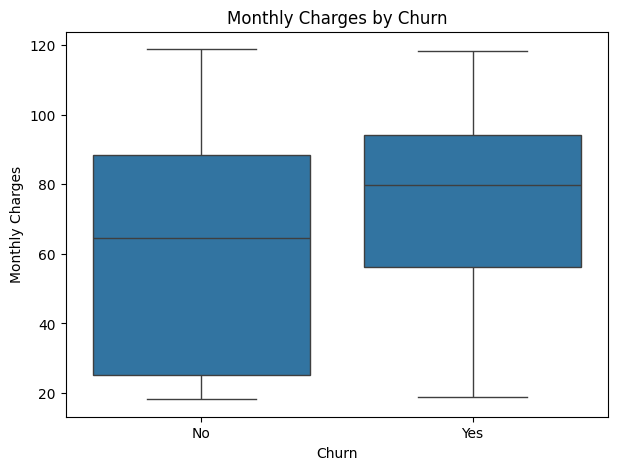

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

Customers who churned generally had higher monthly charges than customers who stayed.



/tmp/ipykernel_6316/103219378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn',y='tenure',palette='Set2')


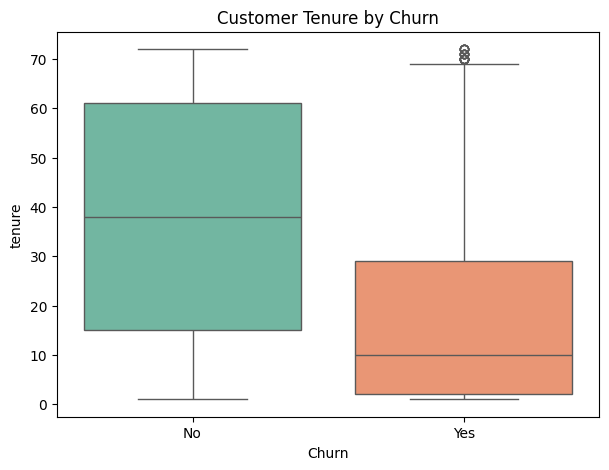

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x='Churn',y='tenure',palette='Set2')
plt.title('Customer Tenure by Churn')
plt.show()

Customers with shorter tenure are more likely to churn.

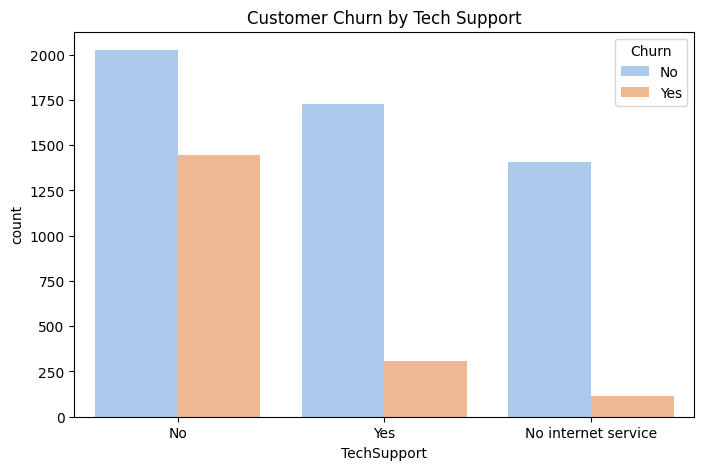

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x='TechSupport',hue='Churn',palette='pastel')
plt.title('Customer Churn by Tech Support')
plt.show()

Customers without Tech Support are more likely to churn.

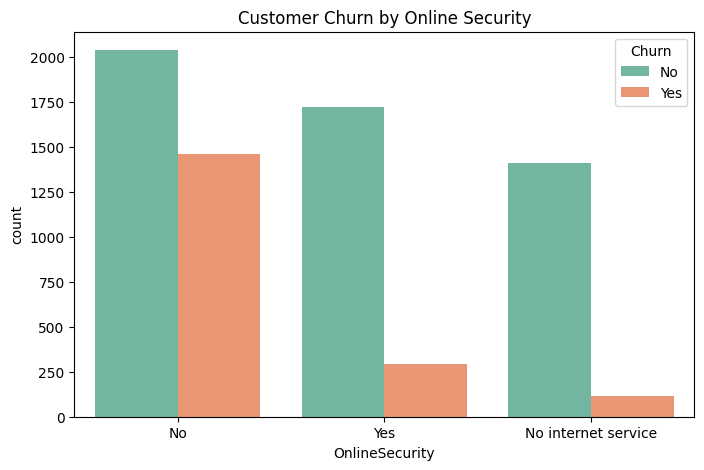

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x='OnlineSecurity',hue='Churn',palette='Set2')
plt.title('Customer Churn by Online Security')

plt.show()

Customers without Online Security have a higher churn rate.

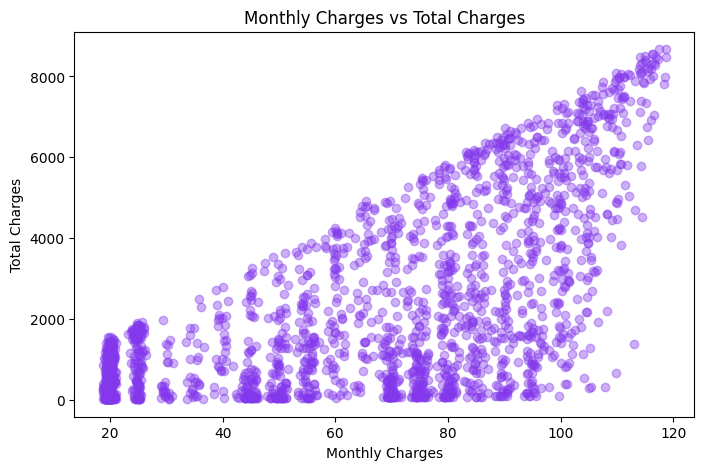

In [ ]:
sample = df.sample(2000, random_state=42)
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(sample['MonthlyCharges'], sample['TotalCharges'],alpha=0.4,color='#8338EC')
ax.set_title('Monthly Charges vs Total Charges')
ax.set_xlabel('Monthly Charges')
ax.set_ylabel('Total Charges')

plt.show()

There is a positive relationship between Monthly Charges and Total Charges.

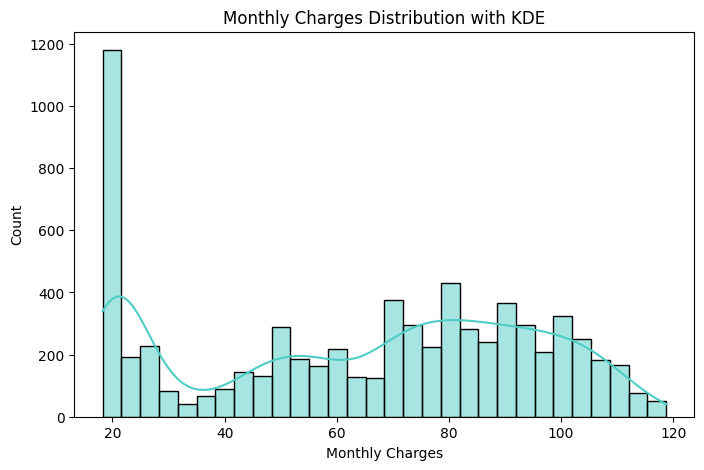

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyCharges'],
             bins=30,
             kde=True,
             color='#4ECDC4')

plt.title('Monthly Charges Distribution with KDE')
plt.xlabel('Monthly Charges')

plt.show()

Most customers pay moderate monthly charges.

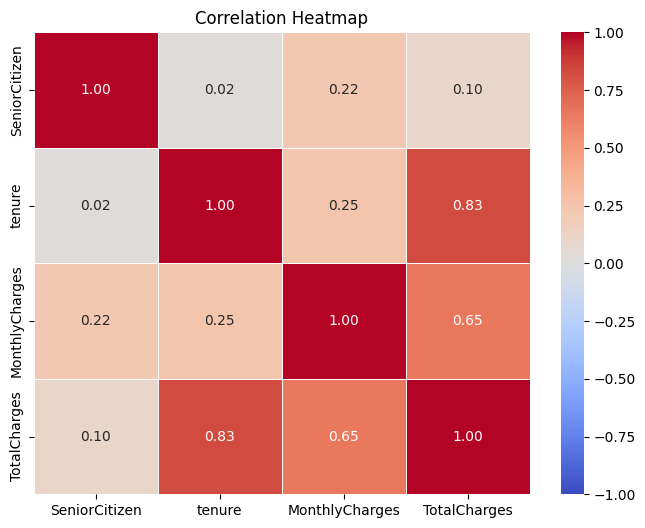

In [ ]:
corr = df[['SeniorCitizen', 'tenure', 'MonthlyCharges','TotalCharges']].corr()
plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Total Charges have a strong positive correlation with Tenure.

---



/tmp/ipykernel_6316/2001108956.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


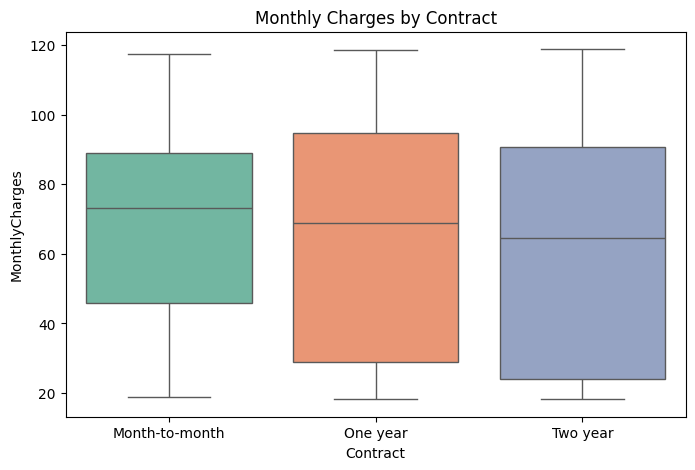

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,x='Contract',y='MonthlyCharges',palette='Set2')
plt.title('Monthly Charges by Contract')
plt.show()

Month-to-month contract customers generally have higher monthly charges compared to other contract types.

  # **-------- ML Model --------**



---



---



**step1:** import libraries

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score,
    RocCurveDisplay
)

**step2:** Determine Features and Target

In [ ]:
X = df.drop(["customerID","Churn"], axis=1)
y = df["Churn"]

X = pd.get_dummies(X, drop_first=True)


**step3:** split data to test and train

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X ,
    y ,
    test_size = 0.2 ,
    random_state = 42 ,
    stratify = y
)

**step4:** Logistic Regression models

In [ ]:
model = LogisticRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**step5:** Evaluate the model efficiency

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="Yes"))
print("Recall   :", recall_score(y_test, y_pred, pos_label="Yes"))
print("F1 Score :", f1_score(y_test, y_pred, pos_label="Yes"))
print("ROC AUC  :", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

Accuracy : 0.7974413646055437
Precision: 0.6336336336336337
Recall   : 0.5641711229946524
F1 Score : 0.5968882602545968
ROC AUC  : 0.8367288568159819


# **Applying Business Strategies to Reduce Customer Churn**

**strategy 1** : The company offered a 10% discount to all customers

In [ ]:
X_discount = X.copy()

X_discount["MonthlyCharges"] *= 0.80

before_prob = model.predict_proba(X)[:, 1]
after_prob = model.predict_proba(X_discount)[:, 1]

print(f"Average Churn Probability Before : {before_prob.mean():.2%}")
print(f"Average Churn Probability After  : {after_prob.mean():.2%}")
print(f"Improvement                     : {(before_prob.mean()-after_prob.mean()):.2%}")

Average Churn Probability Before : 26.68%
Average Churn Probability After  : 25.60%
Improvement                     : 1.08%


**Strategy 2** : The company kept the discount and assumed that 20% of customers switched to a one-year contract.

In [ ]:
X_strategy = X.copy()

X_strategy["MonthlyCharges"] *= 0.8

selected = X_strategy.sample(frac=0.20, random_state=42).index

X_strategy.loc[selected, "Contract_One year"] = True
X_strategy.loc[selected, "Contract_Two year"] = False

before_prob = model.predict_proba(X)[:, 1]
after_prob = model.predict_proba(X_strategy)[:, 1]

print("Churn Probability Before :", (before_prob.mean() * 100), "%")
print("Churn Probability After  :", after_prob.mean() * 100, "%")
print("Improvement :", (before_prob.mean() - after_prob.mean()) * 100, "%")



Churn Probability Before : 26.683071645313177 %
Churn Probability After  : 24.598504064317737 %
Improvement : 2.084567580995442 %


**Strategy 3** : The company maintained the previous strategy and additionally provided free technical support to those customers.

In [ ]:

X_strategy = X.copy()

np.random.seed(100)
selected = np.random.choice(
    X_strategy.index,
    size=int(len(X_strategy) *0.30),
    replace=False
)

X_strategy.loc[selected, "MonthlyCharges"] *= 0.80

X_strategy.loc[selected, "TechSupport_Yes"] = True
X_strategy.loc[selected, "TechSupport_No internet service"] = False

X_strategy.loc[selected, "Contract_One year"] = True
X_strategy.loc[selected, "Contract_Two year"] = False

before = model.predict_proba(X)[:, 1].mean()
after = model.predict_proba(X_strategy)[:, 1].mean()

print(f"Average Churn Probability Before : {before:.2%}")
print(f"Average Churn Probability After  : {after:.2%}")
print(f"Improvement \t \t \t : {(before-after):.2%}")

Average Churn Probability Before : 26.68%
Average Churn Probability After  : 23.23%
Improvement 	 	 	 : 3.45%


Among these scenarios, the combined strategy achieved the largest reduction in predicted churn probability, making it the most effective approach for improving customer retention.

**Conclusion**

This project used exploratory data analysis and a Logistic Regression model to predict customer churn. The results showed that customers with month-to-month contracts, high monthly charges, short tenure, and no Tech Support are more likely to leave.

The model achieved good performance with 79.7% accuracy and a ROC-AUC score of 0.84. Business strategy simulations also showed that offering discounts, encouraging one-year contracts, and improving technical support can help reduce churn. Among all tested scenarios, the combined strategy achieved the best improvement.




Recommendations:

1. Encourage customers to choose long-term contracts.

2. Improve Tech Support and Online Security services.

3. Offer retention plans for customers with a high risk of churn.

4. Improve Fiber Optic service quality and pricing.











Save Clean Data

In [ ]:
df.to_csv("cleaned_churn_data.csv", index=False)